In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\JANANI SHANMUGAM\OneDrive\Desktop\PDA\Regionwise_Sales_EDA_Dataset.csv")

# View data
print(df.head())

# Structure
print(df.info())

# Statistical summary
print(df.describe())

# Column names
print(df.columns)

         Date Branch    Category  Gross_Sales  Discount_Rate  Net_Sales  \
0  2024-01-07   East    Clothing    132999.38           0.11  138894.07   
1  2024-01-14   West  Home Decor    155806.34           0.23  120502.40   
2  2024-01-21  North    Clothing    157326.81           0.03  152953.23   
3  2024-01-28   East     Grocery    132141.21           0.12  115867.19   
4  2024-02-04   East  Home Decor    196644.36           0.00  216086.21   

   Customer_Count  Returned_Items  Holiday_Week  
0             153              19             1  
1             230              10             0  
2             383               9             0  
3             488               7             0  
4             355               5             1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            200 non-null    object 
 1   Branc

In [4]:
# Check missing values
print(df.isnull().sum())

# Drop missing values (if any)
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Create new features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Verify changes
print(df.head())

Date              0
Branch            0
Category          0
Gross_Sales       0
Discount_Rate     0
Net_Sales         0
Customer_Count    0
Returned_Items    0
Holiday_Week      0
dtype: int64
        Date Branch    Category  Gross_Sales  Discount_Rate  Net_Sales  \
0 2024-01-07   East    Clothing    132999.38           0.11  138894.07   
1 2024-01-14   West  Home Decor    155806.34           0.23  120502.40   
2 2024-01-21  North    Clothing    157326.81           0.03  152953.23   
3 2024-01-28   East     Grocery    132141.21           0.12  115867.19   
4 2024-02-04   East  Home Decor    196644.36           0.00  216086.21   

   Customer_Count  Returned_Items  Holiday_Week  Month  Day  
0             153              19             1      1    7  
1             230              10             0      1   14  
2             383               9             0      1   21  
3             488               7             0      1   28  
4             355               5             1     

In [5]:
# Total Gross Sales by Branch
branch_sales = df.groupby('Branch')['Gross_Sales'].sum()
print(branch_sales)

# Average Net Sales
avg_net_sales = np.mean(df['Net_Sales'])
print("Average Net Sales:", avg_net_sales)

# Customer count by Category
category_customers = df.groupby('Category')['Customer_Count'].sum()
print(category_customers)

# Returned items analysis
returns = df['Returned_Items'].sum()
print("Total Returned Items:", returns)

# Holiday vs Non-Holiday Sales
holiday_sales = df.groupby('Holiday_Week')['Net_Sales'].mean()
print(holiday_sales)

Branch
East     8166263.14
North    7086269.72
South    6915386.74
West     8169151.65
Name: Gross_Sales, dtype: float64
Average Net Sales: 136986.7673
Category
Clothing       16220
Electronics    12610
Grocery        15696
Home Decor     17064
Name: Customer_Count, dtype: int64
Total Returned Items: 2514
Holiday_Week
0    131537.445570
1    157486.596667
Name: Net_Sales, dtype: float64


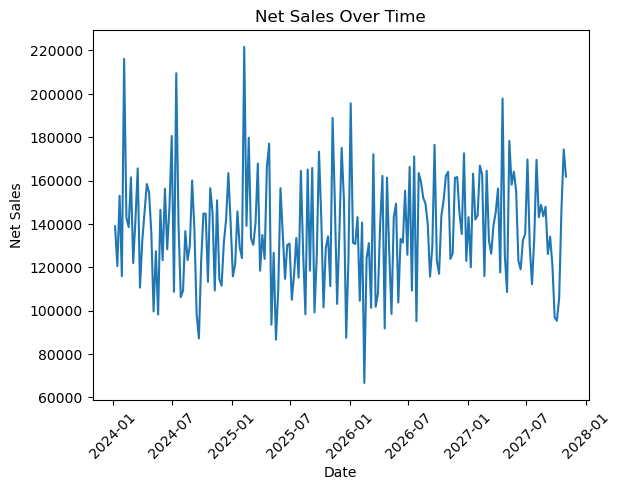

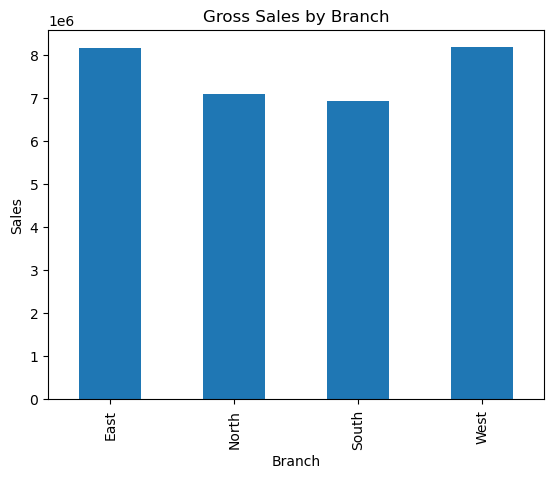

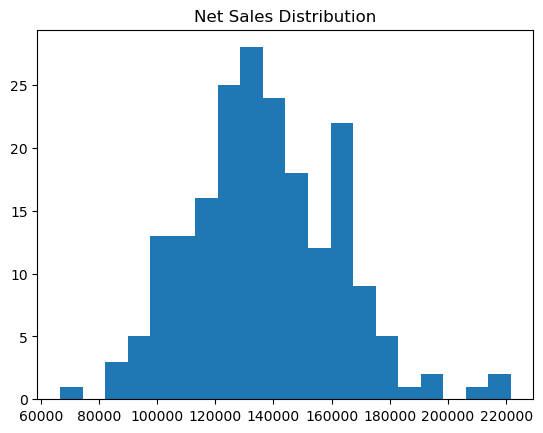

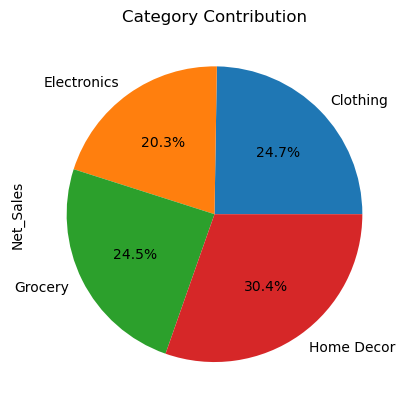

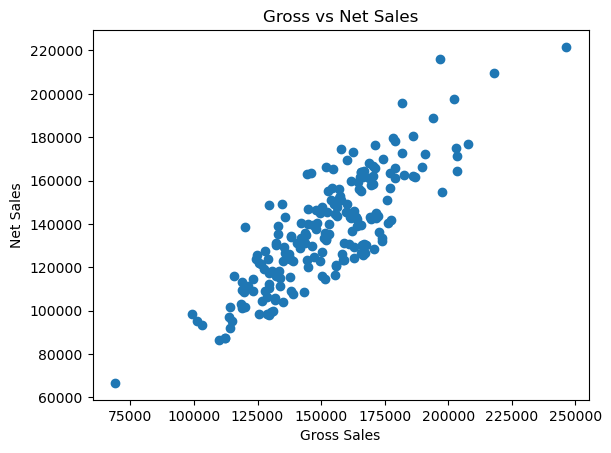

In [6]:
import matplotlib.pyplot as plt

# 1 Line Chart - Net Sales over time
plt.plot(df['Date'], df['Net_Sales'])
plt.title("Net Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.show()

# 2 Bar Chart - Gross Sales by Branch
branch_sales.plot(kind='bar')
plt.title("Gross Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.show()

# 3 Histogram - Net Sales Distribution
plt.hist(df['Net_Sales'], bins=20)
plt.title("Net Sales Distribution")
plt.show()

# 4 Pie Chart - Category Contribution
category_sales = df.groupby('Category')['Net_Sales'].sum()
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Contribution")
plt.show()

# 5 Scatter Plot - Gross vs Net Sales
plt.scatter(df['Gross_Sales'], df['Net_Sales'])
plt.title("Gross vs Net Sales")
plt.xlabel("Gross Sales")
plt.ylabel("Net Sales")
plt.show()

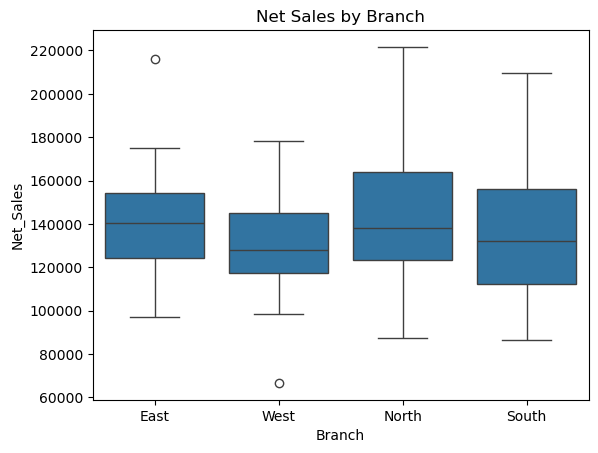

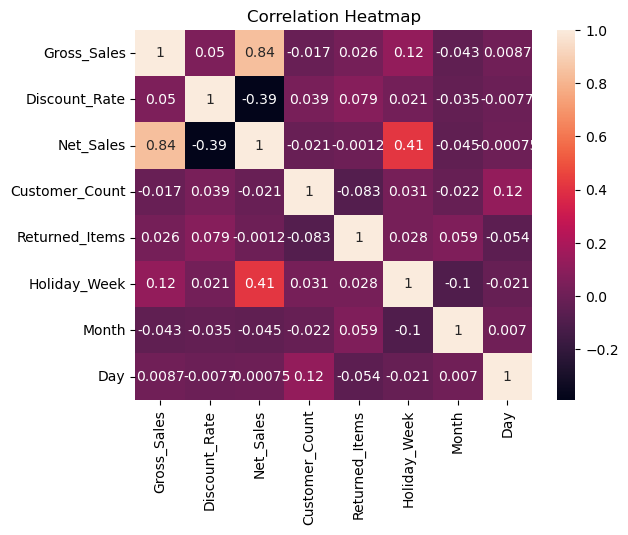

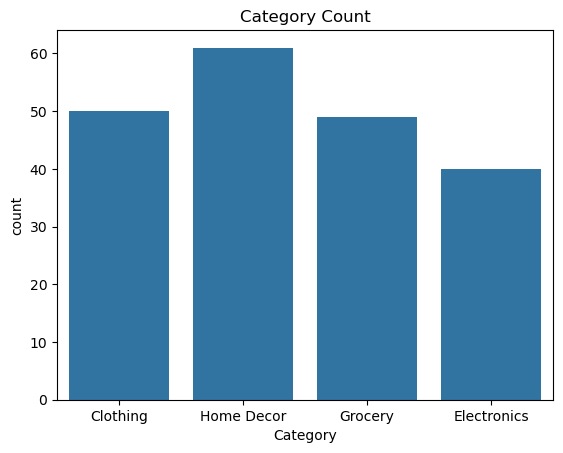

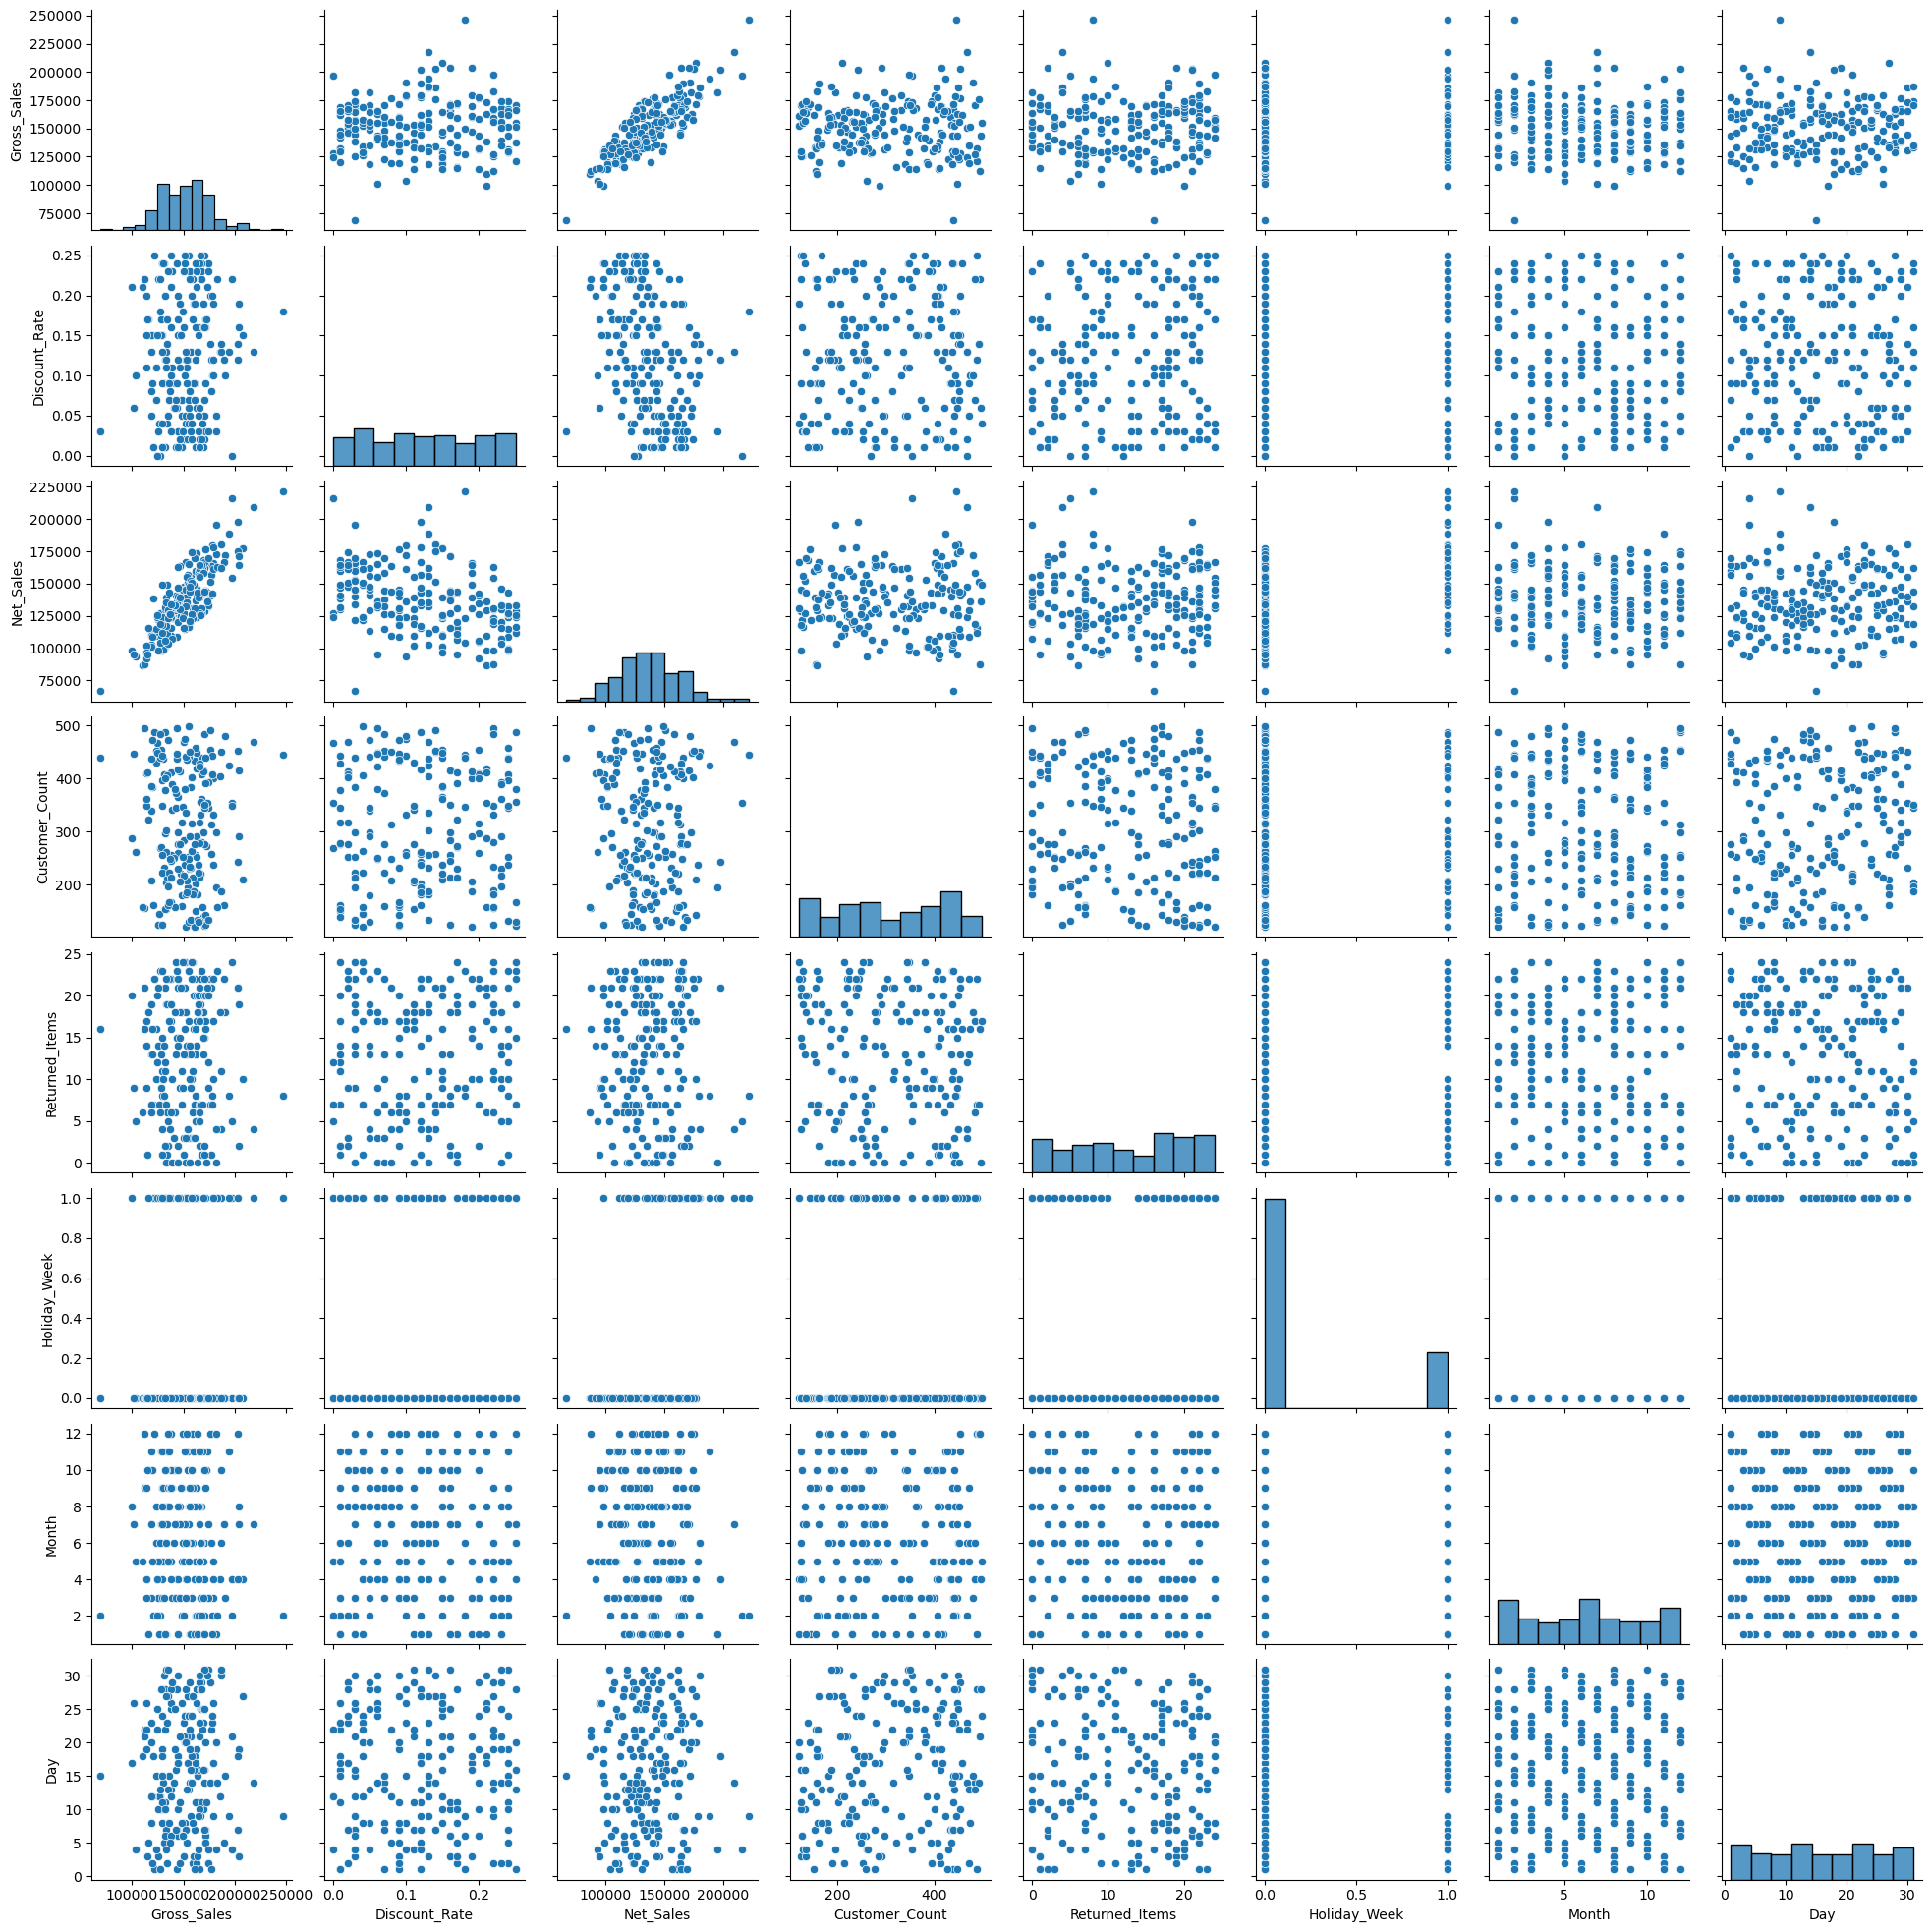

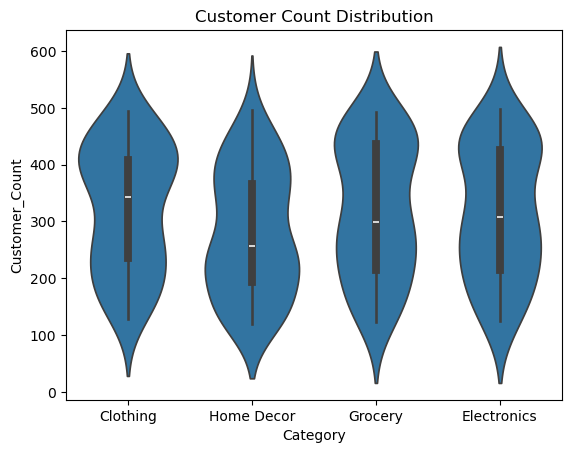

In [7]:
import seaborn as sns

# 6 Boxplot - Net Sales by Branch
sns.boxplot(x='Branch', y='Net_Sales', data=df)
plt.title("Net Sales by Branch")
plt.show()

# 7 Heatmap - Correlation
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 8 Countplot - Category Distribution
sns.countplot(x='Category', data=df)
plt.title("Category Count")
plt.show()

# 9 Pairplot
sns.pairplot(df)
plt.show()

# 10 Violin Plot - Customer Count by Category
sns.violinplot(x='Category', y='Customer_Count', data=df)
plt.title("Customer Count Distribution")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Features & Target
X = df[['Gross_Sales', 'Discount_Rate', 'Customer_Count', 'Returned_Items']]
y = df['Net_Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.8967120343202752


In [9]:
total_net_sales = df['Net_Sales'].sum()
print("Total Net Sales:", total_net_sales)

Total Net Sales: 27397353.46


In [10]:
avg_discount = df['Discount_Rate'].mean()
print("Average Discount Rate:", avg_discount)

Average Discount Rate: 0.1241


In [11]:
branch_sales = df.groupby('Branch')['Gross_Sales'].sum()
top_branch = branch_sales.idxmax()

print("Top Branch:", top_branch)
print(branch_sales)

Top Branch: West
Branch
East     8166263.14
North    7086269.72
South    6915386.74
West     8169151.65
Name: Gross_Sales, dtype: float64


In [12]:
category_customers = df.groupby('Category')['Customer_Count'].sum()
print(category_customers)

Category
Clothing       16220
Electronics    12610
Grocery        15696
Home Decor     17064
Name: Customer_Count, dtype: int64


In [13]:
total_returns = df['Returned_Items'].sum()
print("Total Returned Items:", total_returns)

Total Returned Items: 2514


In [14]:
holiday_sales = df.groupby('Holiday_Week')['Net_Sales'].mean()
print(holiday_sales)

Holiday_Week
0    131537.445570
1    157486.596667
Name: Net_Sales, dtype: float64


In [15]:
corr = df.corr(numeric_only=True)
print(corr)

                Gross_Sales  Discount_Rate  Net_Sales  Customer_Count  \
Gross_Sales        1.000000       0.050147   0.840133       -0.016767   
Discount_Rate      0.050147       1.000000  -0.390235        0.038648   
Net_Sales          0.840133      -0.390235   1.000000       -0.020564   
Customer_Count    -0.016767       0.038648  -0.020564        1.000000   
Returned_Items     0.026240       0.079020  -0.001212       -0.083249   
Holiday_Week       0.122315       0.020960   0.414105        0.031116   
Month             -0.042822      -0.035199  -0.044670       -0.021918   
Day                0.008663      -0.007669  -0.000746        0.120627   

                Returned_Items  Holiday_Week     Month       Day  
Gross_Sales           0.026240      0.122315 -0.042822  0.008663  
Discount_Rate         0.079020      0.020960 -0.035199 -0.007669  
Net_Sales            -0.001212      0.414105 -0.044670 -0.000746  
Customer_Count       -0.083249      0.031116 -0.021918  0.120627  
Returne

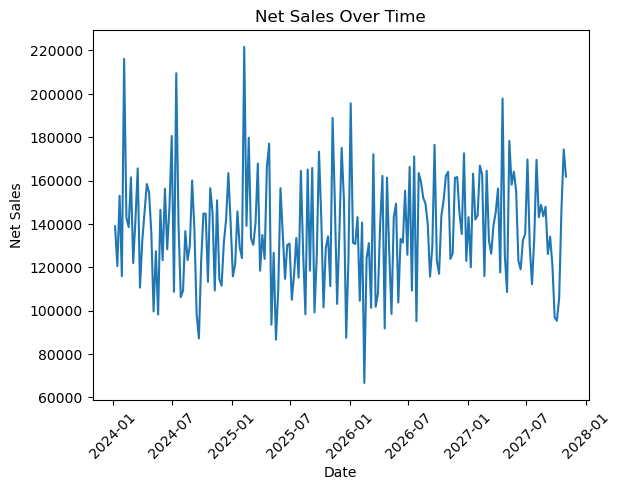

In [16]:
import matplotlib.pyplot as plt

plt.plot(df['Date'], df['Net_Sales'])
plt.title("Net Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.show()

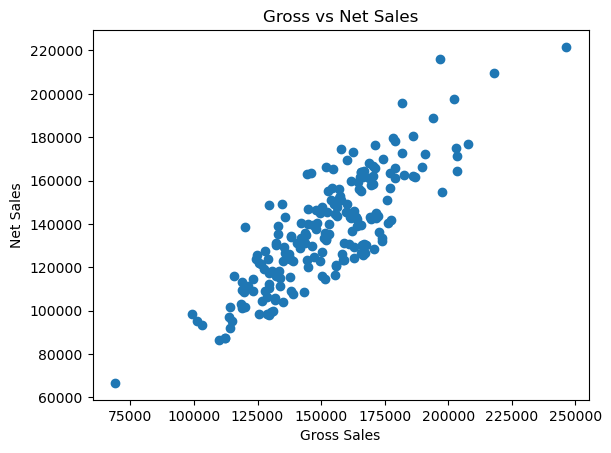

In [17]:
plt.scatter(df['Gross_Sales'], df['Net_Sales'])
plt.title("Gross vs Net Sales")
plt.xlabel("Gross Sales")
plt.ylabel("Net Sales")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Gross_Sales', 'Discount_Rate', 'Customer_Count', 'Returned_Items']]
y = df['Net_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Predictions:", pred[:5])

Predictions: [ 97483.82783588 168036.6449022   96356.99612601 149561.42501994
 144354.81524478]
